# <span style="color:blue;font-weight:bold;font-size:1.1em">Day 6: The <span style="color:red">.group</span> and <span style="color:red">.pivot</span> Methods</span> 

- The <span style="color:blue;font-weight:bold;font-size:1.1em">.group</span> and <span style="color:blue;font-weight:bold;font-size:1.1em">.pivot</span> table methods, and the differences between them.
- The use of statistical functions with **grouping tables** and **pivot tables** to compute stats by groups.
- The creation of Pareto charts using:
  - **.group**
  - **.sort**
  - **.barh**

In [73]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')
survey = Table.read_table('welcome_survey_v4.csv')

## <span style="color:blue; font-weight:bold; font-size:1.1em">1. The <span style="color:red">.group</span> Method</span>

The .group method creates a <span style="color:blue; font-weight:bold; font-size:1.1em">grouping table</span> for a category variable that
1. Lists each **level** of the category variable, and
2. Provides a **count** for how many individuals (rows in the table) exhibit this level.

Example: In the **personality** dataset loaded above as **pers**, we have the **SitClass** variable. The command<center><span style="color:blue; font-weight:bold; font-size:1.2em">pers.group('SitClass')</span></center></br>will create the grouping table and counts we wish to see.

In [74]:
pers.group('SitClass')

SitClass,count
B,28
F,45
M,56


### Practice Question: In the **pers** table, create a grouping table for **Res** (residence status).

### Practice Question: In the **births** table, create a grouping table for **Maternal Smoker**.

### <span style="color:blue; font-weight:bold; font-size:1.1em">Horizontal Bar Graphs Based on a Grouping Table</span>

We can visually compare and contrast the counts using the **.barh** method. However, this method works on the grouping table, se we must be careful of the syntax when creating one. **First**, we create the grouping table: <center><span style="color:blue; font-weight:bold; font-size:1.2em">births.group( 'Materanl Smoker' )</span></center></br>
**Next**, we create the horizontal bar chart by adding a .barh() onto the command shown above:
<center><span style="color:blue; font-weight:bold; font-size:1.2em">births.group( 'Materanl Smoker' ).barh( 'Maternal Smoker' )</span></center></br>

Note that Python reads and **applies the methods** in order from **left to right**.

A horizontal bar chart in sorted in descending order from the top of the graph is called a <span style="color:red; font-weight:bold; font-size:1.2em">Pareto</span> chart.

In [88]:
births.group('Maternal Smoker')   # Grouping Table

Maternal Smoker,count
False,715
True,459


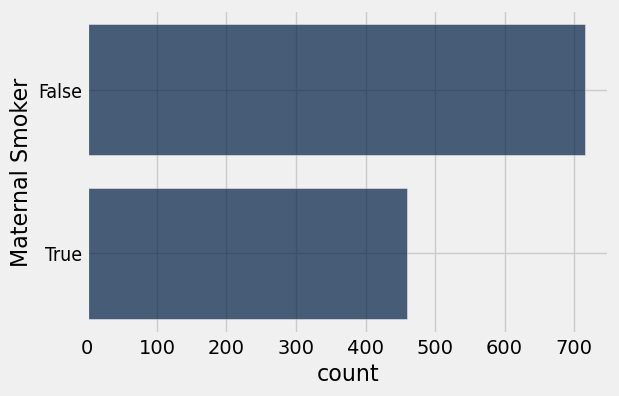

In [76]:
births.group('Maternal Smoker').barh(0)   # Visualization -- note that column numbers can substitute for column titles.

### Practice Question: In the **pers** table, create a grouping table and horizontal bar chart for **Res** (residence status).

### Practice Question: In the **survey** table, create a grouping table and horizontal bar chart for **Handedness**.

## <span style="color:blue; font-weight:bold; font-size:1.1em">2. The <span style="color:red">.pivot</span> Method</span>

The .pivot method creates a <span style="color:blue; font-weight:bold; font-size:1.1em">pivot table</span> for two category variables that
1. Lists one variable **horizontally**, and
2. Lists the other variable **vertically**.

Example: In the **personality** dataset, we can see if the variable <span style="color:red">**biological sex**</span> affects the preferences in the <span style="color:red">***SitClass**</span>. variable. The command<center><span style="color:blue; font-weight:bold; font-size:1.2em">pers.pivot( 'SitClass', 'Sex' )</span></center></br>will create the pivot table which also called a **2-way table** and a **contingency table**.

In [77]:
pers.pivot('SitClass','Sex')

Sex,B,F,M
F,8,32,34
M,20,13,22


### Practice Question: In the **survey** table, create a pivot table for **Year** and **Hours of sleep**.

In [78]:
pivot_yr_hrs = ...

### Practice Question: In the **pers** table, create a pivot table for **PHS** and **Corps**.

In [79]:
pivot_phs_cadet = ...

## <span style="color:blue; font-weight:bold; font-size:1.1em">3. Using .group with Multiple Variables</span>

If we provide a <span style="color:blue; font-weight:bold; font-size:1.1em">list</span>, the .group method will work well. A list is entered using square brackets:<center><span style="color:blue; font-weight:bold; font-size:1.2em">['SitClass', 'Sex']</span></center></br>So the whole command will look like this:<center><span style="color:blue; font-weight:bold; font-size:1.2em">pers.group(['SitClass', 'Sex'])</span></center></br>

In [80]:
pers.group(['SitClass', 'Sex'])

SitClass,Sex,count
B,F,8
B,M,20
F,F,32
F,M,13
M,F,34
M,M,22


### <span style="color:blue; font-weight:bold; font-size:1.1em">For comparison, the <span style="color:red">Grouping Table</span> is above and displays the <span style="color:red">same informaton</span> as the <span style="color:red">Pivot Table</span> below.</span>

In [81]:
pers.pivot('SitClass', 'Sex')

Sex,B,F,M
F,8,32,34
M,20,13,22


### <span style="color:blue; font-weight:bold; font-size:1.1em">We can also use a list with 3 (or more) variables.</span>

<span style="color:red; font-weight:bold; font-size:1.1em">Careful!! The grouping table may grow VERY large!</span>

**Uncomment the command below to see a 3-variable grouping table.**

In [82]:
#survey.group(['Handedness', 'Sleep position', 'Year']).show()

## <span style="color:blue; font-weight:bold; font-size:1.1em">4. Adding Statistics to .group or .pivot</span>

For example purposes, let's create a simplified version of the **pers** table with 2 category variables and a numeric variable **Perf** representing perfectionism levels.

In [83]:
perfect = pers.select('Sex', 'SitClass', 'Perf')
perfect.show(2)

Sex,SitClass,Perf
M,F,105
F,M,105


### <span style="color:blue; font-weight:bold; font-size:1.1em">4a. Adding an Average to a Grouping Table</span>

The .group method provides an easy way to get a statistic rather than the count:<center><span style="color:blue; font-weight:bold; font-size:1.2em">perfect.group('SitClass', np.average)</span></center></br>

The averages are calculated for each level of the category variable and for each numeric column in the original table.

In [84]:
perfect = perfect.drop('Sex')   # Rids final table of unwanted column.
perfect.group('SitClass', np.average)

SitClass,Perf average
B,103.786
F,114.2
M,105.929


### Practice Question: In the **births** table, create a grouping table for **Maternal Smoker** with an average value for  **Birth Weight**.

In [85]:
smoke = ...

### <span style="color:blue; font-weight:bold; font-size:1.1em">4b. Adding an Average to a Pivot Table</span>

The .pivot method requires a bit more work:<center><span style="color:blue; font-weight:bold; font-size:1.1em">pers.pivot('SitClass', 'Sex', values = 'Perf', collect = np.average)</span></center></br>

- The **column title** for where the calcluations happen is identified by <center><span style="color:blue; font-weight:bold; font-size:1.1em">values = 'Perf'</span></center></br>
- The **calculation** to be completed is identified by <center><span style="color:blue; font-weight:bold; font-size:1.1em">collect = np.average</span></center></br>

In contrast to the .group method, this calculation does not cascade to every single numeric column in the table.

In [72]:
pers.pivot('SitClass', 'Sex', values = 'Perf', collect = np.average)

Sex,B,F,M
F,110.375,113.562,106.676
M,101.15,115.769,104.773


### Practice Question: In the **pers** table, create a pivot table for **AccDate** and biological **Sex** variables with an average value for **Narc** (narcissism).

In [87]:
pers.pivot('AccDate', 'Sex', values = 'Narc', collect = np.average)

Sex,N,Y
F,4.39286,3.67391
M,6.42857,4.92593


### <span style="color:blue; font-weight:bold; font-size:1.1em">5. Practice Questions</span>

### Practice Question: In the **survey** table, create a grouping table for **Sleep Position** leaving all other columns in the **survey** table. Add an **np.mean** statistic to the grouping table.

In [94]:
survey_sleep = ...

### Practice Question: In the **survey** table, create a grouping table for **Sleep Position** with a <span style="color:red; font-weight:bold; font-size:1.1em">Pareto chart</span> of the results.

In [95]:
survey_sleep_Pareto = ...

### Practice Question: In the **survey** table, create a grouping table for **Hours of Sleep** and **Year** with an **np.average** statistic calculated.

In [96]:
sleep_year = ...

### Practice Question: Take the prior example and create a <span style="color:red; font-weight:bold; font-size:1.1em">Pareto chart</span> of the results.

sleep_year_Pareto = ...

### Practice Question: In the **survey** table, create a pivot table for **Handedness** and **Sleep Position** with an **np.mean** statistic calculated for **Extroversion**.

In [97]:
hand_position_extro = ...

### Practice Question: For each **city** in the **sky** table, what is the tallest building for each material?

In [98]:
sky_tallest = ...

### Practice Question: generate a table of the names of the **oldest buildings** for each **material** for each **city**.

The user-defined function below will help us out.

In [99]:
# The ident() function below returns the name of the building in the specified row of the table.

def ident(x):
    return x.item(0)

In [100]:
oldest = ...